In [1]:
import polars as pl

In [2]:
markets = pl.read_parquet('data/processed/markets_political.parquet')

eligible = markets.with_columns(
    ((pl.col('end_date') - pl.col('created_at'))
    .dt.total_days()
    .alias('days_active'))
).filter(pl.col('days_active') >= 60)

print(f"Markets with 60+ days active: {len(eligible)}")
print(f"Total markets: {len(markets)}")
print(f"Percentage surviving: {len(eligible)/len(markets)*100:.1f}%")

Markets with 60+ days active: 4606
Total markets: 20689
Percentage surviving: 22.3%


In [3]:
eligible = markets.with_columns(
    ((pl.col('end_date') - pl.col('created_at'))
    .dt.total_days()
    .alias('days_active'))
).filter(pl.col('days_active') >= 60)

# Class balance
print("Class balance:")
print(eligible['resolved_yes'].value_counts())

# Date range
print(f"\nDate range: {eligible['end_date'].min()} → {eligible['end_date'].max()}")

# Sample questions to sense check what markets remain
print("\nSample questions:")
print(eligible.sample(10, seed=42).select(['question', 'days_active']))

Class balance:
shape: (2, 2)
┌──────────────┬───────┐
│ resolved_yes ┆ count │
│ ---          ┆ ---   │
│ bool         ┆ u32   │
╞══════════════╪═══════╡
│ true         ┆ 933   │
│ false        ┆ 3673  │
└──────────────┴───────┘

Date range: 2021-01-02 00:00:00+00:00 → 2026-12-31 12:00:00+00:00

Sample questions:
shape: (10, 2)
┌─────────────────────────────────┬─────────────┐
│ question                        ┆ days_active │
│ ---                             ┆ ---         │
│ str                             ┆ i64         │
╞═════════════════════════════════╪═════════════╡
│ Will Trump nominate Balaji for… ┆ 222         │
│ Will Israel first announce cea… ┆ 132         │
│ Will Trump’s approval rating b… ┆ 112         │
│ Will Jorge 'Tuto' Quiroga qual… ┆ 146         │
│ Will Trump nominate Marty Maka… ┆ 228         │
│ Will a candidate from another … ┆ 248         │
│ Will Trump lower tariffs on Vi… ┆ 117         │
│ Will a Democrat win Montana US… ┆ 236         │
│ Will Samantha Mort

In [5]:
quant = pl.read_parquet('data/processed/quant_filtered.parquet')

eligible_ids = set(eligible['condition_id'].to_list())
eligible_trades = quant.filter(pl.col('condition_id').is_in(eligible_ids))

print(f"\nTrades for eligible markets: {eligible_trades.shape[0]:,}")
print(f"Unique markets with trades: {eligible_trades['condition_id'].n_unique()}")


Trades for eligible markets: 21,600,719
Unique markets with trades: 4436


In [7]:
from datetime import timedelta

quant = pl.read_parquet('data/processed/quant_filtered.parquet')

# Convert timestamp
quant = quant.with_columns(
    pl.from_epoch(pl.col('timestamp'), time_unit='s').alias('datetime')
).with_columns(
    pl.col('datetime').dt.convert_time_zone('UTC').dt.cast_time_unit('ms')
)

# Check how many markets have at least 10 trades in the 60-30 day window
eligible_ids = eligible['condition_id'].to_list()
results = []

for condition_id, end_date in zip(eligible['condition_id'], eligible['end_date']):
    window_end   = end_date - timedelta(days=30)
    window_start = end_date - timedelta(days=60)
    
    market_trades = quant.filter(
        (pl.col('condition_id') == condition_id) &
        (pl.col('datetime') >= window_start) &
        (pl.col('datetime') < window_end)
    )
    
    results.append({
        'condition_id': condition_id,
        'trade_count': len(market_trades)
    })

results_df = pl.DataFrame(results)
viable = results_df.filter(pl.col('trade_count') >= 10)

print(f"Markets with 10+ trades in 60-30 day window: {len(viable)}")
print(results_df['trade_count'].describe())

Markets with 10+ trades in 60-30 day window: 2621
shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ value       │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 4606.0      │
│ null_count ┆ 0.0         │
│ mean       ┆ 698.868867  │
│ std        ┆ 8283.200278 │
│ min        ┆ 0.0         │
│ 25%        ┆ 0.0         │
│ 50%        ┆ 30.0        │
│ 75%        ┆ 202.0       │
│ max        ┆ 486086.0    │
└────────────┴─────────────┘


In [8]:
results_45 = []

for condition_id, end_date in zip(eligible['condition_id'], eligible['end_date']):
    window_end   = end_date - timedelta(days=15)
    window_start = end_date - timedelta(days=45)
    
    market_trades = quant.filter(
        (pl.col('condition_id') == condition_id) &
        (pl.col('datetime') >= window_start) &
        (pl.col('datetime') < window_end)
    )
    
    results_45.append({
        'condition_id': condition_id,
        'trade_count': len(market_trades)
    })

results_45_df = pl.DataFrame(results_45)
viable_45 = results_45_df.filter(pl.col('trade_count') >= 10)
print(f"Markets with 10+ trades in 45-15 day window: {len(viable_45)}")

Markets with 10+ trades in 45-15 day window: 2389


In [9]:
import mlflow

client = mlflow.tracking.MlflowClient()
for rm in client.search_registered_models():
    print(f"Model name: {rm.name}")
    for version in rm.latest_versions:
        print(f"  Version: {version.version}")
        print(f"  Run ID: {version.run_id}")

Model name: polymarket-xgboost
  Version: 4
  Run ID: 4ef73d2af964440d9d75de22597acefd


In [10]:
# It will be version 4 most likely
model = mlflow.xgboost.load_model("models:/polymarket-xgboost/4")

In [11]:
import polars as pl
from sklearn.metrics import brier_score_loss, roc_auc_score
import numpy as np

train = pl.read_parquet('data/model/train.parquet')
test  = pl.read_parquet('data/model/test.parquet')

# Must match the new EXCLUDE_COLS in model.py
EXCLUDE_COLS = [
    'market_id', 'resolved_yes', 'end_date',
    'price_start', 'price_end', 'price_mean',
    'price_min', 'price_max'
]
FEATURE_COLS = [c for c in train.columns if c not in EXCLUDE_COLS]

X_train = train.select(FEATURE_COLS)
y_train = train.select('resolved_yes')
X_test  = test.select(FEATURE_COLS)
y_test  = test.select('resolved_yes')

# Confirm feature list
print(f"Features used: {FEATURE_COLS}")
print(f"Number of features: {len(FEATURE_COLS)}")

Features used: ['price_volatility', 'price_range', 'price_momentum', 'log_total_volume', 'log_trade_count', 'log_avg_trade_size', 'buy_ratio', 'log_market_volume', 'days_active', 'days_to_resolution']
Number of features: 10


In [12]:
# Train vs test
y_train_proba = model.predict_proba(X_train.to_numpy())[:, 1]
y_test_proba  = model.predict_proba(X_test.to_numpy())[:, 1]

print(f"Train Brier: {brier_score_loss(y_train.to_numpy(), y_train_proba):.4f} | Test Brier: {brier_score_loss(y_test.to_numpy(), y_test_proba):.4f}")
print(f"Train AUC:   {roc_auc_score(y_train.to_numpy(), y_train_proba):.4f}  | Test AUC:   {roc_auc_score(y_test.to_numpy(), y_test_proba):.4f}")

Train Brier: 0.0950 | Test Brier: 0.0790
Train AUC:   0.9529  | Test AUC:   0.9399


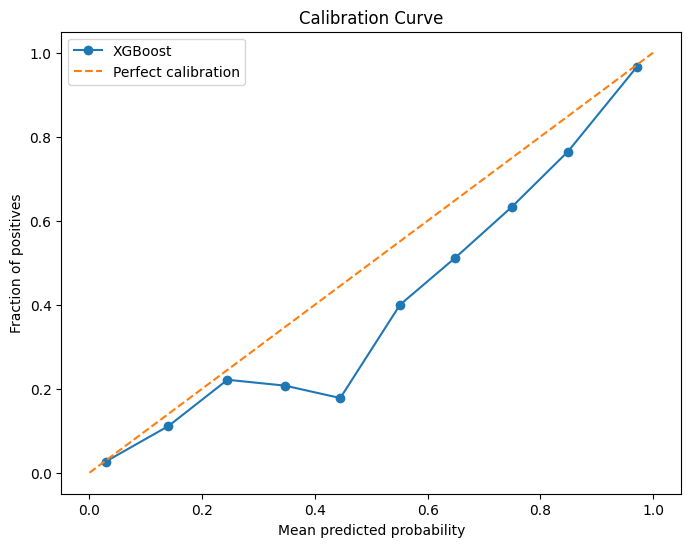

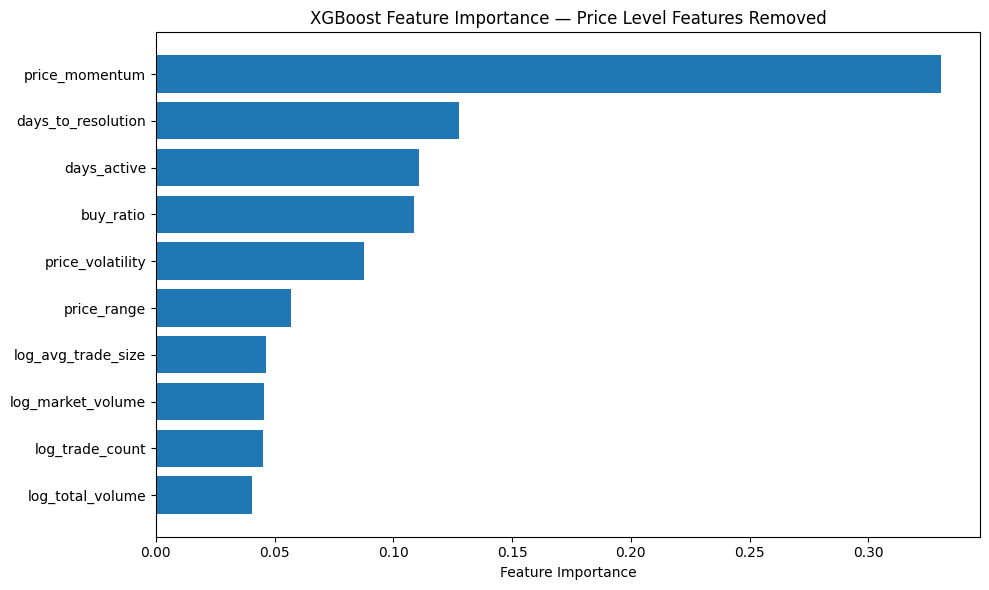

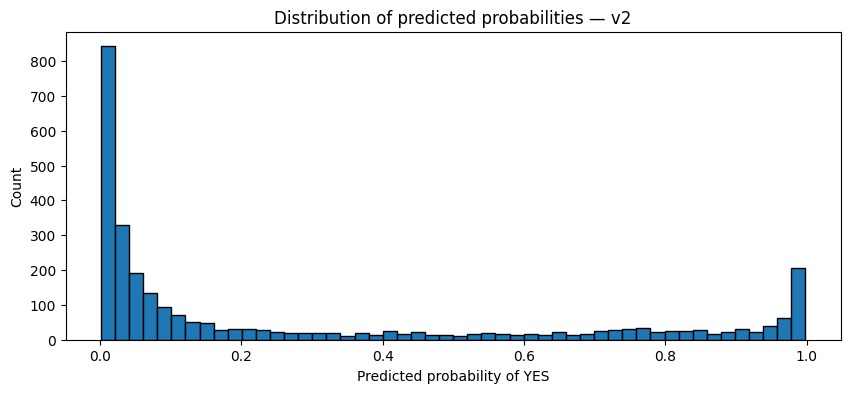

price_volatility: 0.3488
price_range: 0.3405
price_momentum: 0.5399
log_total_volume: 0.2709
log_trade_count: 0.1169
log_avg_trade_size: 0.3455
buy_ratio: 0.4953
log_market_volume: 0.1535
days_active: -0.1294
days_to_resolution: 0.1799


In [13]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import pandas as pd

# Check 2 — Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test.to_numpy(), y_test_proba, n_bins=10
)

plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.savefig('calibration_curve_v2.png')
plt.show()

# Check 3 — Feature importance
feature_names = FEATURE_COLS
importances = model.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance — Price Level Features Removed')
plt.tight_layout()
plt.savefig('feature_importance_v2.png')
plt.show()

# Check 4 — Prediction distribution
plt.figure(figsize=(10, 4))
plt.hist(y_test_proba, bins=50, edgecolor='black')
plt.xlabel('Predicted probability of YES')
plt.ylabel('Count')
plt.title('Distribution of predicted probabilities — v2')
plt.savefig('prediction_distribution_v2.png')
plt.show()

# Check correlations
for col in FEATURE_COLS:
    corr = np.corrcoef(
        test[col].to_numpy(),
        y_test.to_numpy().ravel()
    )[0,1]
    print(f"{col}: {corr:.4f}")